<a href="https://colab.research.google.com/github/The-Professor99/ML_Practice/blob/main/hands_on_learning/transformers_agents_multiagents/00_multi_agent_systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LangGraph is a library designed to build stateful, multi-actor applications with LLMs, chains, and tools. It extends LangChain by allowing you to define sequences of calls (chains) more robustly, with cycles, conditional logic, and the ability to manage complex state transitions. This makes it ideal for creating agentic workflows where multiple thinking and acting steps are required, or where different specialized agents need to collaborate.

It's becoming a trend that a powerful AI agent gets created by combining several smaller subagents. But this also brings challenges like reducing hallucinations, managing the conversation flow, keeping an eye on how the agent works during testing, allowing human in the loop, and evaluating its performance.

Why Multi-Agent?
Multi-agent architectures are powerful for several reasons:

Specialization & Modularity: Instead of a single, monolithic agent trying to handle everything, a multi-agent system comprises smaller, specialized agents. Each agent is optimized for a specific task or domain (e.g., one for music queries, another for invoice details). This improves accuracy and performance within their specialized area.
Flexibility & Scalability: New capabilities can be added by simply integrating a new specialized agent, without needing to retrain or significantly modify existing agents. Agents can be quickly added, removed, or modified, making the system highly adaptable.
Robustness: If one agent fails or performs poorly in its specific task, it doesn't necessarily bring down the entire system, as other agents can still function. This contributes to a more resilient application.
Complex Problem Solving: Many real-world problems require different types of expertise. A multi-agent system can mimic human team collaboration, breaking down complex queries into sub-problems handled by the most appropriate expert agent.

In [ ]:
!pip install langchain_openai

In [ ]:
!pip install langchain_community

In [ ]:
!pip install langchain-openrouter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.4/396.4 kB 7.8 MB/s eta 0:00:00


In [ ]:
from dotenv import load_dotenv # Import function to load environment variables
# from langchain_openai import ChatOpenAI # Import the OpenAI chat model
from langchain_openrouter import ChatOpenRouter as ChatOpenAI # Import the OpenRouter chat model

# Load environment variables from the .env file. The `override=True` argument
# ensures that variables from the .env file will overwrite existing environment variables.
load_dotenv(dotenv_path=".env", override=True)


True

When we build AI agentic apps with LLMs, Langsmaith helps us understand and improve them. It works like a dashboard that shows what is happening inside your app and lets you:
- Debug when things go wrong.
- Test your prompts and logic
- Evaluate how good the answers are
- Monitor your app in real time
- Track usage, speed, and cost

In [ ]:
from langsmith import utils

# Check and print whether LangSmith tracing is currently enabled
print(f"Langsmith tracing is enabled: {utils.tracing_is_enabled()}")

Langsmith tracing is enabled: True


We'll be using OpenAI's models in this example, but LangGraph is model-agnostic, so you can easily swap ChatOpenAI with other ChatModel providers like Azure OpenAI, Anthropic, or Google Gemini.

In [ ]:
# Initialize the ChatOpenAI model. We're using a specific model from Llama 3.3 series.
# This `model` object will be used throughout the notebook for all LLM interactions.
llm = ChatOpenAI(model_name="meta-llama/Llama-3.3-70B-Instruct", temperature=0)

In [ ]:
import sqlite3
import requests
from langchain_community.utilities.sql_database import SQLDatabase
from sqlalchemy import create_engine
from sqlalchemy.pool import StaticPool

In [ ]:
def get_engine_for_chinook_db():
    """
    Pull SQL file, populate in-memory database, and create engine.

    Downloads the Chinook database SQL script from GitHub and creates an
    in-memory SQLite database populated with the sample data.

    Returns:
        sqlalchemy.engine.Engine: SQLAlchemy engine connected to the in-memory database
    """
    # Download the Chinook database SQL script from the official repository
    url = "https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sql"
    response = requests.get(url)
    sql_script = response.text

    # Create an in-memory SQLite database connection
    # check_same_thread=False allows the connection to be used across threads
    connection = sqlite3.connect(":memory:", check_same_thread=False)

    # Execute the SQl script to populate the database with sample data
    connection.executescript(sql_script)

    # Create and return a SQLAlchemy engine that uses the populated connection
    return create_engine(
        "sqlite://", # SQLite URL scheme
        creator=lambda: connection, # Function that returns the database connection
        poolclass=StaticPool, # Use StaticPool to maintain single connection
        connect_args={"check_same_thread": False}, # Allow cross-thread usage
    )

In [ ]:
# Initialize the database engine with the Chinook sample data
engine = get_engine_for_chinook_db()

# Creates a Langchain SQLDatabase wrapper around the engine
# This provides convenient methods for database operations and query execution
db = SQLDatabase(engine)

In any intelligent agent, memory plays an important role. Just like humans, an AI agent needs to remember past interactions to maintain context and provide personalized responses.

in LangGraph:
- Short term memory helps an agent keep track of the current conversation. This is handled by a MemorySaver, which saves and resumes the state of the conversation.
- Long-term memory which lets the agent remember information across different conversations, like user preferences. For example, we can use an InMemoryStore for quick storage, but in real apps, we'd use a more permanent database.

In [ ]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore

# Initialize long-term memory store for persistent data between conversations
in_memory_store = InMemoryStore()

# Initialize checkpointer for short-term memory within a single thread/conversation
checkpointer = MemorySaver()

/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


Our goal is to build a realistic customer support agent which is not a single agent but through a multi-agent workflow in LangGraph.

We'll start from a simplet ReAct agent and add additional steps into the workflow, simulating a realistic customer example, showcasing human-in-the-loop, long term memory, and the LangGraph pre-built library.

Our multi-agent workflow will contain 2 specialized ReAct sub-agents which we will combine to create a multi-agent workflow.

Workflow:
- Human Input: user provides account information.
- Verify info: The system checks the account and clarifies the user's intent if needed.
- Load Memory: retrieves the user's music preferences
- Supervisor coordinates two sub-agents: music data and billing
- Create Memory: updates the user's memory with new information from the interaction

First sub-agent is a music catalog information agent. It's primary role is to assist customers with inquiries related to our digital music catalog, such as searching for artists, albums, or songs.

Defining state, tools, and nodes in LangGraph:
- State: holds the current data snapshot flowing through the graph (basically the agent's memory).
- Each node updates this state as the conversation progresses.
- Tools are functions that let the LLM do things it can't do on its own, like calling APIs or accessing databases

In [ ]:
from typing_extensions import TypedDict
from typing import Annotated, List
from langgraph.graph.message import AnyMessage, add_messages
from langgraph.managed.is_last_step import RemainingSteps

class State(TypedDict):
    """
    State schema for the multi-agent customer support workflow.

    This defines the shared data structure that flows between nodes in the graph,
    representing the current snapshot of the conversation and agent state.
    """
    # Customer identifier retrieved from account verification
    customer_id: str

    # Conversation history with automatic message aggregation
    messages: Annotated[List[AnyMessage], add_messages]

    # User preferences and context.loaded from long-term memory store
    loaded_memory: str

    # Counter to prevent infinite loops in the agent workflow
    remaining_steps: RemainingSteps

The State class will serve as the blueprint for how information is managed and passed between different parts of our multi-agent system.

We'll define python functions and mark them with @tool from langchain_core.tools so the LLM can find and use them when needed.

In [ ]:
from langchain_core.tools import tool
import ast

@tool
def get_albums_by_artist(artist: str):
    """
    Get albums by an artist from the Chinook Music database.

    Args:
        artist (str): Name of the artist to search for albums.

    Returns:
        str: Database query results containing album titles and artist names
    """
    return db.run(
        f"""
        SELECT Album.Title, Artist.Name
        FROM Album
        JOIN Artist ON Album.ArtistId = Artist.ArtistId
        WHERE Artist.Name LIKE '%{artist}%';
        """,
        include_columns=True
    )

@tool
def get_tracks_by_artist(artist: str):
    """
    Get tracks by an artist (or similar artists) from the Chinook Music database.

    Args:
        artist (str): Name of the artist to search for tracks.

    Returns:
        str: Database query results containing track titles and artist names
    """
    return db.run(
        f"""
        SELECT Track.Name as SongName, Artist.Name as ArtistName
        FROM Album
        LEFT JOIN Artist ON Album.ArtistId = Artist.ArtistId
        LEFT JOIN Track ON Track.AlbumId = Album.AlbumId
        WHERE Artist.Name LIKE '%{artist}%';
        """,
        include_columns=True
    )

@tool
def get_songs_by_genre(genre: str):
    """
    Get songs by genre from the Chinook Music database.

    This function first looks up the genre ID(s) for the given genre name,
    then retrieves tracks that belong to those genre(s), limiting results
    to 8 songs grouped by artist

    Args:
        genre (str): Name of the genre to search for songs.

    Returns:
        list[dict] or str: List of songs with their artist information that match
        the specified genre, or an error message if no songs are found.
    """
    # Step 1: Look up genre ID(s) for the given genre name
    genre_results = db.run(
        f"""
        SELECT GenreId
        FROM Genre
        WHERE Name LIKE '%{genre}%';
        """
    )

    if not genre_results:
        return f"No songs found for the genre: '{genre}'."

    # Parse the genre IDs and format them for the SQL query
    genre_ids = ast.literal_eval(genre_ids)
    genre_id_list = ", ".join(str(genre_id[0]) for genre_id in genre_ids)


    # Step 2: Retrieve tracks that belong to the identified genre(s)
    track_results = db.run(
            f"""
            SELECT Track.Name as SongName, Artist.Name as ArtistName
            FROM Track
            JOIN Album ON Track.AlbumId = Album.AlbumId
            JOIN Artist ON Album.ArtistId = Artist.ArtistId
            WHERE Track.GenreId IN ({genre_id_list})
            GROUP BY Artist.Name, Track.Name
            LIMIT 8;
            """,
            include_columns=True
        )

    # Check if any songs were found
    if not track_results:
        return f"No songs found for genre '{genre}'."

    # Format the  results into a list of dictionaries for better readability
    formatted_tracks = ast.literal_eval(track_results)

    return [
        {
            "Song": track["SongName"],
            "Artist": track["ArtistName"]
        }
        for track in formatted_tracks
    ]

@tool
def check_for_songs(song_title):
    """
    Check if a song exists in the Chinook Music database by title.

    Args:
        song_title (str): Title of the song to search for.

    Returns:
        str: Database query results containing all track information
        for songs that match the given title.
    """
    return db.run(
        f"""
        SELECT * FROM Track
        WHERE Name LIKE '%{song_title}%';
        """,
        include_columns=True
    )


In [ ]:
# Create a list of all music-related tools to be used by the agents in the graph
music_tools = [
    get_albums_by_artist,
    get_tracks_by_artist,
    get_songs_by_genre,
    check_for_songs
]

# Bind the tools to the language model for use in the ReAct agent
llm_with_music_tools = llm.bind_tools(music_tools)

This allows the LLM to understand when and how to call these functions based on the user's query

Let's define the nodes of our graph.
Nodes are the core processing units in a LangGraph application that take the graph current state as input, perform some logic, and return an updated state

For our ReAct agent, we will define two key types of nodes:
- music_assistant is the LLM reasoning node. It uses the current conversation history and memory to decide the next action, either calling a tool or generating a response, and updates the State
- music_tool_node: runs the tool selected by music_assistant. Langgraph ToolNode manages the tool call and updates the State with the result.

By combining these nodes, we enable dynamic reasoning and action within our multi-agent workflow

In [ ]:
from langgraph.prebuilt import ToolNode

# Create a tool node that executes the music related tools
# ToolNode is a pre-built LangGraph component that handles tool execution
music_tool_node = ToolNode(music_tools)

We'll define the music_assistant node. This node will use our LLM (with the music_tools bound to it) to determine the next action. It also incorporates any loaded_memory into its prompt, allowing for personalized response.

In [ ]:
from langchain_core.messages import ToolMessage, SystemMessage, HumanMessage
from langchain_core.runnables import RunnableConfig

def generate_music_assistant_prompt(memory: str = "None") -> str:
    """
    Generate a system prompt for the music assistant agent.

    Args:
        memory (str): User preferences and context from long-term memory store

    Returns:
        str: Formatted system prompt for the music assistant
    """
    return f"""
    You are a member of the assistant team, your role specifically is to focus on helping
    customers discover and learn about music in our digital catalog.
    If you  are unable to find playlists, songs, or albums associated with an artist, it is okay.
    Just inform the customer that the catalog does not have any playlists, songs, or albums associated with that artist.
    You also have context on any saved user preferences, helping you to tailor your response.

    CORE RESPONSIBILITIES:
    - Search and provide accurate information about songs, albums, playlists, and artists in our music catalog.
    - Offer relevant recommendations based on customer interests
    - Handle music-related queries with attention to detail
    - Help customers discover new music they might enjoy
    - You are routed only when there are questions related to music catalog; ignore other questions.

    SEARCH GUIDELINES:
    1. Always perform thorough searching before concluding something is unavailable
    2. If exact matches aren't found, try:
        - Checking for alternative spellings
        - Looking for similar artist names
        - Searching by partial matches
        - Checking different versions/remixes
    3. When providing song lists:
        - Including the artist name with each song
        - Mention the album when relevant
        - Note if it's part of any playlists
        - Indicate if there are multiple versions

    Additional context is provided below:

    Prior saved user preferences: {memory}

    Message history is also attached.
    """

In [ ]:
def music_assistant(state: State, config: RunnableConfig):
    """
    Music assistant node that handles music catalog queries and recommedations.

    This node processes customer requests related to music discover, album searches,
    artist information, and personalized recommendations based on stored preferences.

    Args:
        state (State): Current state containing customer_id, messages, loaded_memory, etc.
        config (RunnableConfig): Configuration for the runnable execution

    Returns:
        dict: Updated state with the assistant's response message
    """
    # Retrieve long-term memory preferences if available
    memory = "None"
    if "loaded_memory" in state:
        memory = state["loaded_memory"]

    # Generate the system prompt for the music assistant using the retrieved memory
    system_prompt = generate_music_assistant_prompt(memory)

    # Invoke the Language model with tools and system prompt
    # The model can decide whether to use tools or respond directly based on the input query and context
    response = llm_with_music_tools.invoke([SystemMessage(system_prompt)] + state["messages"])

    # Return updated state with the assistant's response
    return {"messages": [response]}

The music_assistant node constructs a detailed system prompt for the LLM, including general instructions and the loaded_memory for personalization. It then invokes the llm_with_music_tools with this system message and current conversation messages and returns an LLM response which add_messages (from our State definition) will automatically append to the messages list in the State.

With our State and Nodes in place, the next step is to connect them using Edges, which define the execution flow in the graph.
- Normal edges always route from one specific node to another
- Conditional edges are dynamic, they are python functions that examine the current state and decide which node to visit next.

For our ReAct agent, we need a conditional edge that checks whether the music_assistant should:
- Invoke tools: If the LLM decides to call a tool, we route to music_tool_node to execute it
- End the process, if the LLM provides a final response without tool calls, we conclude the sub-agent's execution

In [ ]:
def should_continue(state: State, config: RunnableConfig):
    """
    Conditional edge function that determines the next step in the ReAct agent workflow.

    This function examines the last message in the conversation to decide whether the
    agent should continue with tool execution or end the conversation.

    Args:
        state (State): Current state containing messages and other workflow data
        config (RunnableConfig): Configuration for the runnable execution

    Returns:
        str: Either "continue" to execute tools or "end" to finish the workflow
    """
    # Get all messages from the current state
    messages = state["messages"]

    # Examine the most recent message to check for tool calls
    last_message = messages[-1]

    # if the last message doesn't contain any tool calls, the agent is done
    if not last_message.tool_calls:
        return "end"

    return "continue"

Since we have all the pieces: State, Nodes, and Edges.
Let's assemble them to construct our complete ReAct agent using StateGraph

In [ ]:
from IPython.display import Image

In [ ]:
def show_graph(graph, xray=False):
    """
    Display a LangGraph mermaid diagram with fallback rendering.

    This function attempts to render a LangGraph as a visual diagram using Mermaid.
    It includes error handling to fall back to an alternative renderer if the default fails.

    Args:
        graph: The LangGraph object that has a get_graph() method for visualization
        xray (bool): Whether to show internal graph details in xray mode

    Returns:
        Image: An IPython Image object containing the rendered graph diagram
    """

    try:
        # Try the default mermaid renderer first (uses mermaid.ink service)
        # This is the fastest option but may fail due to network issues or service unavailability
        return Image(graph.get_graph(xray=xray).draw_mermaid_png())
    except Exception as e:
        # If the default renderer fails, fall back to pyppeteer
        # pyppeteer uses a local headless Chrome instance to render the diagram
        print(f"Default renderer failed ({e}), falling back to pyppeteer...")

        # Apply nest_asyncio to handle async operations in Jupyter environments
        # This is necessary because pyppeteer uses async operations
        import nest_asyncio
        nest_asyncio.apply()

        # Import the MermaidDrawMethod enum for specifying the draw method
        from langchain_core.runnables.graph import MermaidDrawMethod

        # Use pyppeteer as the drawing method (local rendering)
        return Image(graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER))

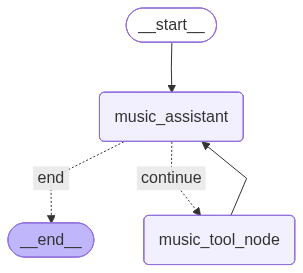

In [ ]:
from langgraph.graph import StateGraph, START, END

# Create a new StateGraph instance for the music workflow
music_workflow = StateGraph(State)

# Add nodes to the graph
# music_assistant: The reasoning node that decides which tools to invoke
music_workflow.add_node("music_assistant", music_assistant)
# music_tool_node: The execution node that handles all music-related tool calls
music_workflow.add_node("music_tool_node", music_tool_node)

# Add edges to define the flow of the graph
# Set the entry point - all queries start with the music assistant
music_workflow.add_edge(START, "music_assistant")

# Add conditional edge from music_assistant based on whether tools need to be called
music_workflow.add_conditional_edges(
    "music_assistant",
    # Conditional function that determines the next step
    should_continue,
    {
        # If tools need to be executed, route to tool node
        "continue": "music_tool_node",
        # If no tools needed, end the workflow
        "end": END
    }
)

# After tool execution, always return to the music assistant for further processing
music_workflow.add_edge("music_tool_node", "music_assistant")

# Compile the graph with checkpointer for short-term memory and store for long-term memory
music_catalog_subagent = music_workflow.compile(
    name="music_catalog_subagent",
    checkpointer=checkpointer,
    store=in_memory_store
)

# Display the compiled graph structure
show_graph(music_catalog_subagent)

Testing our First Sub-agent

In [ ]:
import uuid

# Generate a unique thread ID for this conversation session
thread_id = uuid.uuid4()

# Define the user's question about music recommendations
question = "I like the Rolling Stones. What songs do you recommend by them or by other artists that I might like?"

# Set up configuration with the thread ID for maintaining conversation context
config = {
    "configurable": {
        "thread_id": thread_id
    }
}

# Invoke the music catalog subagent with the user's question
# The agent will use its tools to search for Rolling Stones music and provide recommendations
result = music_catalog_subagent.invoke({
    "messages": [HumanMessage(content=question)]
}, config=config)

# Display all messages from the conversation in a formatted way
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

I like the Rolling Stones. What songs do you recommend by them or by other artists that I might like?
================================== Ai Message ==================================
Tool Calls:
  get_tracks_by_artist (chatcmpl-tool-471840161e8e428eb3e0bc38e910abf6)
 Call ID: chatcmpl-tool-471840161e8e428eb3e0bc38e910abf6
  Args:
    artist: Rolling Stones
================================= Tool Message =================================
Name: get_tracks_by_artist

[{'SongName': 'Time Is On My Side', 'ArtistName': 'The Rolling Stones'}, {'SongName': 'Heart Of Stone', 'ArtistName': 'The Rolling Stones'}, {'SongName': 'Play With Fire', 'ArtistName': 'The Rolling Stones'}, {'SongName': 'Satisfaction', 'ArtistName': 'The Rolling Stones'}, {'SongName': 'As Tears Go By', 'ArtistName': 'The Rolling Stones'}, {'SongName': 'Get Off Of My Cloud', 'ArtistName': 'The Rolling Stones'}, {'SongName': "Mother's Little Help

Let's then create our second sub agent. While building a ReAct agent from scratch is great for understanding the fundamentals, LangGraph also offers pre-built libraries for common architectures. This allows us to quickly setup standard patterns like ReAct without manually defining all nodes and edges.

In [ ]:
from langchain_core.tools import tool

@tool
def get_invoices_by_customer_sorted_by_date(customer_id: str) -> list[dict]:
    """
    Look up all invoices for a customer using ther ID.
    The invoices are sorted in descending order by invoice date,
    which helps when the customer wants to view their most recent/oldest invoice,
    or if they want to view invoices within a specific date range.

    Args:
        customer_id (str): customer_id, which serves as the identifier.

    Returns:
        list[dict]: A list of invoices for the customer
    """
    return db.run(
        f"""
        SELECT * FROM Invoice
        WHERE CustomerId = '{customer_id}'
        ORDER BY InvoiceDate DESC;
        """
    )

@tool
def get_invoices_sorted_by_unit_price(customer_id: str) -> list[dict]:
    """
    Use this tool when the customer wants to view the details of one of  their invoices based on
    the unit price/cost of the invoice.
    This tool looks up all invoices for a customer, and sorts the unit price from highest to lowest.
    In order to find the invoice associated with the customer, we need to know the customer ID.

    Args:
        customer_id (str): customer_id, which serves as the identifier.

    Returns:
        list[dict]: A list of invoices for the customer, sorted by unit price in descending order
    """
    return db.run(
        f"""
        SELECT Invoice.*, InvoiceLine.UnitPrice
        FROM Invoice
        JOIN InvoiceLine ON Invoice.InvoiceId = InvoiceLine.InvoiceId
        WHERE Invoice.CustomerId = '{customer_id}'
        ORDER BY InvoiceLine.UnitPrice DESC;
        """
    )

@tool
def get_employee_by_invoice_and_customer(invoice_id: str, customer_id: str) -> dict:
    """
    This tool will take in an invoice ID and a customer ID and return the
    employee details associated with that invoice and customer.

    Args:
        invoice_id (str): The unique identifier for the invoice.
        customer_id (str): The unique identifier for the customer.

    Returns:
        dict: Employee details associated with the specified invoice and customer
    """
    employee_info = db.run(
        f"""
        SELECT Employee.FirstName, Employee.Title, Employee.Email
        FROM Employee
        JOIN Customer ON Customer.SupportRepId = Employee.EmployeeId
        JOIN Invoice ON Invoice.CustomerId = Customer.CustomerId
        WHERE Invoice.InvoiceId = '{invoice_id}' AND Invoice.CustomerId = '{customer_id}';
        """,
        include_columns=True
    )

    if not employee_info:
        return f"No employee found for the given invoice ID {invoice_id} and customer ID {customer_id}."

    return employee_info

In [ ]:
# Create a list of all invoice-related tools for the agent
invoice_tools = [
    get_invoices_by_customer_sorted_by_date,
    get_invoices_sorted_by_unit_price,
    get_employee_by_invoice_and_customer
]

In [ ]:
invoice_subagent_prompt = """
    You are a subagent among a team of assistants. You are specialized for retrieving
    and processing invoice information. You are routed for invoice-related portion of
    the questions, so only respond to them.

    You have access to three tools. These tools enable you to retrieve and process invoice information from the database. Here are the tools:
    - get_invoices_by_customer_sorted_by_date: This tool retrieves all invoices for a customer, sorted by invoice date.
    - get_invoices_sorted_by_unit_price: This tool retrieves all invoices for a customer, sorted by unit price.
    - get_employee_by_invoice_and_customer: This tool retrieves the employee information associated with an invoice and a customer.

    If you are unable to retrieve the invoice information, inform the customer you are unable to retrieve the information, and ask if they would like to search for something else.

    CORE RESPONSIBILITIES:
    - Retrieve and process invoice information from the database
    - Provide detailed information about invoices, including customer details, invoice dates, total amounts, employees associated with the invoice, etc. when the customer asks for it.
    - Always maintain a professional, friendly, and patient demeanor

    You may have additional context that you should use to help answer the customer's query. It will be provided to you below:
    """

Now, instead of manually creating nodes and conditional edges for the ReAct pattern as we did with our previous sub agent, we will use LangGraph create_react_agent prebuilt function

In [ ]:
from langgraph.prebuilt import create_react_agent

# Create the invoice information subagent using LangGraph's prebuilt ReAct agent
# This agent specializes in handling customer invoice queries and billing information
invoice_information_subagent = create_react_agent(
    llm, # Language model for reasoning and responses
    tools=invoice_tools, # Invoice-specific tools for database queries
    name="invoice_information_subagent", # unique identifier for the agent. Important for multi-agent routing
    prompt=invoice_subagent_prompt, # System instructions for invoice handling
    state_schema=State, # State schema for data flow between nodes
    checkpointer=checkpointer, # Short-term memory for conversation context
    store=in_memory_store, # Long-term memory store for persistent data
)

/tmp/ipykernel_59568/659219598.py:5: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  invoice_information_subagent = create_react_agent(


With just few lines, we have a fully functional ReAct agent, this is the advantage we have using LangGraph.

In [ ]:
# Testing the second subagent

# Generate a unique thread ID for this conversation session
thread_id = uuid.uuid4()

question = "My customer id is 1. What was my most recent invoice, and who was the employee that helped me with it?"

# Set up configuation with the thread ID for maintaining conversation context
config = {
    "configurable": {
        "thread_id": thread_id
    }
}

# Invoke the invoice information subagent with the user's question
# The agent will use its tools to search for invoice information and employee details
result = invoice_information_subagent.invoke({
    "messages": [HumanMessage(content=question)]
}, config=config)

# Display all messages from the conversation in a formatted way
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

My customer id is 1. What was my most recent invoice, and who was the employee that helped me with it?
================================== Ai Message ==================================
Name: invoice_information_subagent
Tool Calls:
  get_invoices_by_customer_sorted_by_date (chatcmpl-tool-89c0e2a5ca500962)
 Call ID: chatcmpl-tool-89c0e2a5ca500962
  Args:
    customer_id: 1
================================= Tool Message =================================
Name: get_invoices_by_customer_sorted_by_date

[(382, 1, '2025-08-07 00:00:00', 'Av. Brigadeiro Faria Lima, 2170', 'São José dos Campos', 'SP', 'Brazil', '12227-000', 8.91), (327, 1, '2024-12-07 00:00:00', 'Av. Brigadeiro Faria Lima, 2170', 'São José dos Campos', 'SP', 'Brazil', '12227-000', 13.86), (316, 1, '2024-10-27 00:00:00', 'Av. Brigadeiro Faria Lima, 2170', 'São José dos Campos', 'SP', 'Brazil', '12227-000', 1.98), (195, 1, '2023-05-06 00:00:00', 'Av.

Creating multi-agent using supervisor

We have 2 sub-agents: one for music questions and one for invoices. A natural question arises: How do we ensure customer tasks are appropriately routed to the correct sub-agent

This is where the concept of a supervisor agent comes into play. It routes customer requests to the right sub-agent based on the query. After a subagent finishes, control goes back to the supervisor or can be passed to another sub-agent.

A supervisor based multi-agent architecture brings key benefits:
- Each subagent focuses on a specific domain, improving accuracy and making it easy to add new agents.
- Agents can be added, removed, or updated without impacting the whole system, supporting scalability.
- Limiting LLMs to specific tasks lowers the chance of wrong or irrelevant outputs.

Let's create a set of instructions for our supervisor. this prompt will define its role, inform it about the available sub-agents and their capabilities, and guide its decision-making process for routing

In [ ]:
supervisor_prompt = """You are an expert customer support assistant for a digital music store.
You are dedicated to providing exceptional service and ensuring customer queries are answered thoroughly.
You have a team of subagents that you can use to help answer queries from customers.
Your primary role is to serve as a supervisor/planner for this multi-agent team that helps answer queries from customers.

Your team is composed of two subagents that you can use to help answer the customer's request:
1. music_catalog_information_subagent: this subagent has access to user's saved music preferences. It can also retrieve information about the digital music store's music
catalog (albums, tracks, songs, etc.) from the database.
3. invoice_information_subagent: this subagent is able to retrieve information about a customer's past purchases or invoices
from the database.

Based on the existing steps that have been taken in the messages, your role is to generate the next subagent that needs to be called.
This could be one step in an inquiry that needs multiple sub-agent calls.

Remember:  You must have called one of the following tools to proceed. Do not respond with text until a tool has been used.
"""

Let's then put our supervisor to work using the create_supervisor function from langGraph pre-built

In [ ]:
!pip install langgraph_supervisor

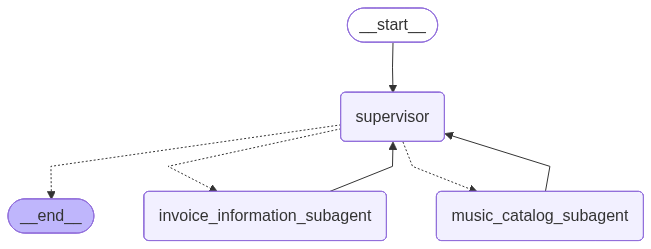

In [ ]:
from langgraph_supervisor import create_supervisor

# Create supervisor workflow using LangGraph's pre-built supervisor
# The supervisor coordinates between multiple subagents based on the incoming queries
supervisor_prebuilt_workflow = create_supervisor(
    agents=[invoice_information_subagent, music_catalog_subagent], # List of subagents to supervise
    output_mode="last_message", # Return only the final response (alternative: "full_history") from the active sub-agent
    model=llm, # Language model for supervisor reasoning and routing decisions
    prompt=(supervisor_prompt), # System instructions for the supervisor agent
    state_schema=State # State schema defining data flow structure
)

# Compile the supervisor workflow with memory components
# - checkpointer: Enables short term memory with conversation threads
# - store: Provides long-term memory storage across conversations
supervisor_prebuilt = supervisor_prebuilt_workflow.compile(
    name="music_catalog_subagent",
    checkpointer=checkpointer,
    store=in_memory_store
)

# Display the compiled supervisor graph structure
show_graph(supervisor_prebuilt)

In [ ]:
# testing our supervisor based multi-agent architecture

thread_id = uuid.uuid4()

question = "My Customer ID is 1. How much was my most recent purchase? What albums do you have by U2?"

# Set up configuration with the thread ID for maintaining conversation context
config = {
    "configurable": {
        "thread_id": thread_id
    }
}

# Invoke the supervisor workflow with the multi-part question
# The supervisor will route the query to the appropriate subagents and return the final response
result = supervisor_prebuilt.invoke({
    "messages": [HumanMessage(content=question)]
}, config=config)

# Display all messages from the conversation in a formatted way
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

My Customer ID is 1. How much was my most recent purchase? What albums do you have by U2?
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_invoice_information_subagent (chatcmpl-tool-9c1450e7d3b81990)
 Call ID: chatcmpl-tool-9c1450e7d3b81990
  Args:
================================= Tool Message =================================
Name: transfer_to_invoice_information_subagent

Successfully transferred to invoice_information_subagent
================================== Ai Message ==================================
Name: invoice_information_subagent

Your most recent purchase was $8.91. I am not able to help you with your question about U2 albums. Would you like to search for something else?
================================== Ai Message ==================================
Name: invoice_information_subagent

Transferring back to supervis

Adding Human-in-the-loop

In the real-world customer support scenario, we don't always have the customer_id readily available. Before allowing an agent to access sensitive information like invoice history, we typically need to verify the customer's identity. Let's enhance our workflow by adding a customer verification layer. This will involve a human-in-the-loop component where the system might pause and prompt the customer to provide their account information if it's missing or unverified.

Let's define a Pydantic schema for parsing user input and a system prompt for an LLM to extract this information reliably

In [ ]:
from pydantic import BaseModel, Field

class UserInput(BaseModel):
    """Schema for parsing user-provided account information."""
    identifier: str = Field(description="Unique identifier for the user, such as customer ID, phone number, or email address")

# Create a structured LLM that outputs responses conforming to the UserInput schema
structured_llm = llm.with_structured_output(UserInput)

# system prompt for extracting customer identification information
structured_system_prompt = """You are a customer service representative responsible for extracting customer identifier.
Only extract the customer's account information from their message history.
If they haven't provided the information yet, return an empty string for the identifier."""

The UserInput pydantic model defines the expected data as a single identifier. We also use "with_structured_output()" to make the LLM return JSON in this format The system prompt helps the LLM focus only on extracting the identifier.

In [ ]:
from typing import Optional

# Helper function for customer identification
def get_customer_id_from_identifier(identifier: str) -> Optional[int]:
    """
    Retrieve customer ID from the database based on a provided identifier (which can be a customer ID, phone number, or email address).

    This function supports three types of identifiers:
    1. Direct customer ID (numeric string)
    2. Phone number (starts with "+")
    3. Email address (contains "@")

    Args:
        identifier (str): The customer identifier provided by the user (customer ID, phone number, or email).

    Returns:
        Optional[int]: The corresponding customer ID if found, otherwise None.
    """
    #C heck if identifier is a direct customer ID (numeric string)
    if identifier.isdigit():
        return int(identifier)

    # Check if identifier is a phone number (starts with "+")
    if identifier.startswith("+"):
        # Query the database to find the customer ID based on the provided phone number
        result = db.run(
            f"""
            SELECT CustomerId
            FROM Customer
            WHERE Phone = '{identifier}';
            """
        )
        formated_result = ast.literal_eval(result)
        if formated_result:
            return formated_result[0][0]

    # Check if identifier is an email address (contains "@")
    if "@" in identifier:
        # Query the database to find the customer ID based on the provided email address
        result = db.run(
            f"""
            SELECT CustomerId
            FROM Customer
            WHERE Email = '{identifier}';
            """
        )
        formated_result = ast.literal_eval(result)
        if formated_result:
            return formated_result[0][0]

    # If no match is found, return None
    return None

In [ ]:
def verify_info(state: State, config: RunnableConfig):
    """
    Verify the customer's account by parsing their input and matching it with the database

    This node handles customer identity verification as the first step in the support process.
    It extracts customer identifiers (ID, email, or phone) from user messages and validates them
    against the database.

    Args:
        state (State): Current state containing messages and other workflow data
        config (RunnableConfig): Configuration for the runnable execution

    Returns:
        dict: Updated state with customer ID if verification is successful, or request for more info
    """
    # Only verify if customer_id is not already set
    if state.get("customer_id") is None:
        # System instructions for prompting customer verification
        system_instructions = """You are a music store agent, where you are trying to verify the customer identity
        as the first step of the customer support process.
        Only after their account is verified, you would be able to support them on resolving the issue.
        In order to verify their identity, one of their customer ID, email, or phone number needs to be provided.
        If the customer has not provided their identifier, please ask them for it.
        If they have provided the identifier but cannot be found, please ask them to revise it."""

        # Get the most recent user message
        user_input = state["messages"][-1]

        # Use structured LLM to parse customer identifier from the message
        parsed_info = structured_llm.invoke([SystemMessage(structured_system_prompt)] + [user_input])

        # Extract the identifier from parsed response
        identifier = parsed_info.identifier

        # Initialize customer_id as empty
        customer_id = ""

        # Attempt to find the customer ID using the provided identifier
        if identifier:
            customer_id = get_customer_id_from_identifier(identifier)

        # If a valid customer ID is found, confirm verification and update the state; otherwise, ask for more information
        if customer_id != "":
            intent_message = SystemMessage(
                content = f"Thank you for providing your information! I was able to verify your account with customer id {customer_id}."
            )
            return {
                "customer_id": customer_id,
                "messages": [intent_message]
            }
        else:
            # If customer not found, ask for correct information
            response = llm.invoke([SystemMessage(system_instructions)] + state["messages"])
            return {"messages": [response]}
    else:
        # If customer_id is already set, no action needed
        pass

Let's then create a human_input node which acts as a placeholder that triggers interrupt() in the graph, pausing execution to wait for user input. This is important for human-in-the-loop interactions, allowing the agent to directly request missing information

In [ ]:
from langgraph.types import interrupt

def human_input(state: State, config: RunnableConfig):
    """
    Human-in-the-loop node that interrupts the workflow to request user input.

    This node creates an interruption point in the workflow, allowing the system
    to pause and wait for human input before continuing. It's typically used for
    customer verification or when additional information is needed.

    Args:
        state (State): Current state containing messages and other workflow data
        config (RunnableConfig): Configuration for the runnable execution

    Returns:
        dict: Updated state with the user's input message
    """
    # Interrupt the workflow and prompt for user input
    user_input = interrupt("Please provide input.")

    # Return the user input as a new message in the state
    return {"messages": [user_input]}

The run_graph function (which we will update later for evaluation) will need to handle this interrupt by providing new input to resume the graph.

In [ ]:
# Conditional edge: should_interrupt
def should_interrupt(state: State, config: RunnableConfig):
    """
    Determines whether the workflow should interrupt and ask  for human input.

    If the customer_id is present in the state (meaning verification is complete),
    the workflow continues. Otherwise, it interrupts to get human input for verification.
    """

    if state.get("customer_id") is None:
        return "interrupt"

    return "continue"

Let's integrate these new nodes and edges into our overall graph

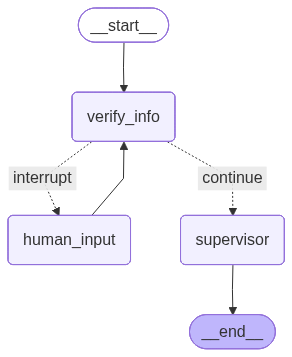

In [ ]:
# Create a new StateGraph instance for the multi-agent workflow with verification
multi_agent_verify = StateGraph(State)

# Add new nodes for customer verification and human input
multi_agent_verify.add_node("verify_info", verify_info)
multi_agent_verify.add_node("human_input", human_input)
# Add the existing supervisor agent as a node
multi_agent_verify.add_node("supervisor", supervisor_prebuilt)

# Define the graph's entry point: always start with information verification
multi_agent_verify.add_edge(START, "verify_info")

# Add a conditional edge from the verification node to determine if we need to interrupt for more info or continue to the supervisor
multi_agent_verify.add_conditional_edges(
    "verify_info",
    should_interrupt,
    {
        "interrupt": "human_input", # If verification is incomplete, interrupt to get more info
        "continue": "supervisor" # If verification is successful, continue to the supervisor agent
    }
)

# After human input, always loop back to verify_info to re-attempt verification
multi_agent_verify.add_edge("human_input", "verify_info")
# After the supervisor completes its task, the workflow ends
multi_agent_verify.add_edge("supervisor", END)

# Compile the complete graph with checkpointer and long-term memory store
multi_agent_verify_graph = multi_agent_verify.compile(
    name="multi_agent_verify",
    checkpointer=checkpointer,
    store=in_memory_store
)

# Display the updated graph structure
show_graph(multi_agent_verify_graph)

Let's test it out. First, we'll ask a question without providing any identification

In [ ]:
thread_id = uuid.uuid4()
question = "How much was my most recent purchase?"
config = {
    "configurable": {
        "thread_id": thread_id
    }
}

result = multi_agent_verify_graph.invoke({
    "messages": [HumanMessage(content=question)]
}, config=config)

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

How much was my most recent purchase?
================================== Ai Message ==================================

Before I can look up your most recent purchase, I need to verify your identity. Can you please provide me with your customer ID, email address, or phone number associated with your account? This will help me to ensure that I'm assisting the correct person and provide you with the accurate information.


As expected, the agent will interrupt and ask for your customer ID, email, or phone number because the customer_id is initially None in the state.

Let's resume the conversation and provide the requested information. LangGraph invoke method can accept a Command(resume=...) to pick up from an interrupt

In [ ]:
from langgraph.types import Command

# Resume from the interrupt, providing the phone number for verification
question = "My phone number is +55 (12) 3923-5555."
result = multi_agent_verify_graph.invoke(Command(resume=question), config=config)
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

How much was my most recent purchase?
================================== Ai Message ==================================

Before I can look up your most recent purchase, I need to verify your identity. Can you please provide me with your customer ID, email address, or phone number associated with your account? This will help me to ensure that I'm assisting the correct person and provide you with the accurate information.
================================ Human Message =================================

My phone number is +55 (12) 3923-5555.
================================ System Message ================================

Thank you for providing your information! I was able to verify your account with customer id 1.
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_invoice_information_subagent (chatcmpl-tool-d8376c13f4214f4caa3779a84205

It confirms the verification and, as defined in our graph, passes control to the supervisor, which then routes the original query. This confirms that our human-in-the-loop verification mechanism works as intended.

One advantage of LangGraph state management is that once customer_id is verified and saved in the State, it persists throughout the conversation. This means the agent won't ask for verification again in follow-up questions within the same thread.

Let's test this persistence by asking a follow-up question without re-providing the ID

In [ ]:
question = "What albums do you have by the Rolling Stones?"
result = multi_agent_verify_graph.invoke({
    "messages": [HumanMessage(content=question)]
}, config=config)
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

How much was my most recent purchase?
================================== Ai Message ==================================

Before I can look up your most recent purchase, I need to verify your identity. Can you please provide me with your customer ID, email address, or phone number associated with your account? This will help me to ensure that I'm assisting the correct person and provide you with the accurate information.
================================ Human Message =================================

My phone number is +55 (12) 3923-5555.
================================ System Message ================================

Thank you for providing your information! I was able to verify your account with customer id 1.
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_invoice_information_subagent (chatcmpl-tool-d8376c13f4214f4caa3779a84205

verify_info node doesn't re-prompt for identification. This shows how State maintains context and avoids repeating steps, improving the user experience.

Adding Long-Term Memory

We've already initialized our InMemoryStore for long-term memory in the "Setting up short-term and long-term memory" section. Now it's time to fully integrate it into our multi-agent workflow. Long term memory is incredibly powerful because it allows the agent to recall and leverage information from past conversations, leading to more personalized and context-aware interactions over time.

We'll add new nodes to handle long-term memory:
- load_memory: retrieves the user's existing preferences from the in_memory_store at the start of the conversation (after verification)
- create_memory: saves any new music interests shared by the user during the conversation to the in_memory_store for future use.

Let's create a helper function to format the user's stored music preferences into a readable string that can be easily injected into an LLM's prompt

In [ ]:
from langgraph.store.base import BaseStore

# Helper function to format user memory data for LLM prompts
def format_user_memory(user_data):
    """Formats music preferences from users, if available."""
    # Access the 'memory' key which holds the UserProfile object
    profile = user_data["memory"]
    result = ""
    # check if music_preferences attribute exists and is not empty
    if hasattr(profile, "music_preferences") and profile.music_preferences:
        result += f"User's music preferences: {", ".join(profile.music_preferences)}"

    return result.strip()

# Node: load memory
def load_memory(state: State, config: RunnableConfig, store: BaseStore):
    """
    Loads music preferences from the long-term memory store for a given user.

    This node retrieves any saved user information (such as music preferences) from the long-term memory store
    and formats it for use in the agent's reasoning process, enabling personalized responses based on the customer's history and preferences.

    Args:
        state (State): Current state containing messages and other workflow data
        config (RunnableConfig): Configuration for the runnable execution

    Returns:
        dict: Updated state with loaded memory information
    """
    # Get the user_id from the configurable part of the config
    # In our evaluation setup, we might pass user_id via config
    user_id = config["configurable"].get("user_id", state["customer_id"]) # Use customer_id from state as fallback if user_id is not provided in config

    # Define the namespace and key for accessing memory in the store
    namespace = ("memory_profile", user_id)
    key = "user_memory"

    # Retrieve existing memory for the user
    existing_memory = store.get(namespace, key)
    formatted_memory = ""

    # Format the retrieved memory if it exists and has content
    if existing_memory and existing_memory.value:
        formatted_memory = format_user_memory(existing_memory.value)

    # Update the state with the loaded and formatted memory
    return {"loaded_memory": formatted_memory}


The load_memory node uses the user"id (from config or state) to build a namespace key and fetch existing user_memory from the in_memory_store. It formats this memory and updates the loaded_memory field in the State. This memory is then included in the music_assistant prompt, as set up in generate_music_assistant_prompt

In [ ]:
# Pydantic model to define the structure of the user proofile for memory
class UserProfile(BaseModel):
    customer_id: str = Field(
        description="The customer ID of the customer"
    )
    music_preferences: list[str] = Field(
        description="A list of the customer's music preferences, such as favorite artists, genres, or albums"
    )

Let's then define the create_memory node. This node will use an LLM-as-a-judge pattern to analyze the conversation history and existing memory, then update the UserProfile with any newly identified music interests.

In [ ]:
# Prompt for the create_memory agent, guiding it to update user memory
create_memory_prompt = """You are an expert analyst that is observing a conversation that has taken place between a customer and a customer support assistant. The customer support assistant works for a digital music store, and has utilized a multi-agent team to answer the customer's request.
You are tasked with analyzing the conversation that has taken place between the customer and the customer support assistant, and updating the memory profile associated with the customer. The memory profile may be empty. If it's empty, you should create a new memory profile for the customer.

You specifically care about saving any music interest the customer has shared about themselves, particularly their music preferences to their memory profile.

To help you with this task, I have attached the conversation that has taken place between the customer and the customer support assistant below, as well as the existing memory profile associated with the customer that you should either update or create.

The customer's memory profile should have the following fields:
- customer_id: the customer ID of the customer
- music_preferences: the music preferences of the customer

These are the fields you should keep track of and update in the memory profile. If there has been no new information shared by the customer, you should not update the memory profile. It is completely okay if you do not have new information to update the memory profile with. In that case, just leave the values as they are.

*IMPORTANT INFORMATION BELOW*

The conversation between the customer and the customer support assistant that you should analyze is as follows:
{conversation}

The existing memory profile associated with the customer that you should either update or create based on the conversation is as follows:
{memory_profile}

Ensure your response is an object that has the following fields:
- customer_id: the customer ID of the customer
- music_preferences: the music preferences of the customer

For each key in the object, if there is no new information, do not update the value, just keep the value that is already there. If there is new information, update the value.

Take a deep breath and think carefully before responding.
"""

In [ ]:
# Node: create_memory
def create_memory(state: State, config: RunnableConfig, store: BaseStore):
    """
    Analyzes conversation history and updates the user's long-term memory profile.

    This node extracts new music preferences shared by the customer during the
    conversation and persists them in the InMemoryStore for future interactions.
    """
    # Get the user_id from the configurable part of the config or from the state
    user_id = str(config["configurable"].get("user_id", state["customer_id"]))

    # Define the namespace and key for the memory profile
    namespace = ("memory_profile", user_id)
    key = "user_memory"

    # Retrieve the existing memory profile for the user
    existing_memory = store.get(namespace, key)

    # Format the existing memory for the LLM prompt
    formatted_memory = ""
    if existing_memory and existing_memory.value:
        existing_memory_dict = existing_memory.value
        # Ensure 'music_preferences' is treated as a list, even if it might be missing or None
        music_prefs = existing_memory_dict.get('music_preferences', [])
        if music_prefs:
            formatted_memory = f"Music Preferences: {', '.join(music_prefs)}"

    # Prepare the system message for the LLM to update memory
    formatted_system_message = SystemMessage(content=create_memory_prompt.format(
        conversation=state["messages"],
        memory_profile=formatted_memory
    ))

    # Invoke the LLM with the UserProfile schema to get structured updated memory
    updated_memory = llm.with_structured_output(UserProfile).invoke([formatted_system_message])

    # Store the updated memory profile
    store.put(namespace, key, {"memory": updated_memory})

The create_memory node retrieves the current user memory from the store, formats it, and sends it along with the full conversation (state["messages"]) to the LLM

The LLM extracts new music preferences into a UserProfile object, merging them with existing data. The updated memory is then saved back to the in_memory_store using store.put

Integrating the memory nodes into our graph:
- load_memory node runs right after verification to load user preferences
- create_memory node runs just before the graph ends, saving any updates

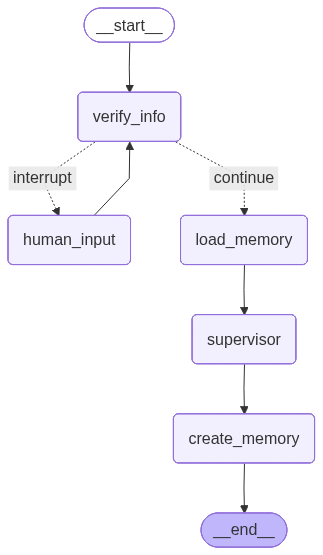

In [ ]:
multi_agent_final = StateGraph(State)

# Add all existing and new nodes to the graph
multi_agent_final.add_node("verify_info", verify_info)
multi_agent_final.add_node("human_input", human_input)
multi_agent_final.add_node("load_memory", load_memory)
multi_agent_final.add_node("supervisor", supervisor_prebuilt)
multi_agent_final.add_node("create_memory", create_memory)

# Define the graph's entry pont: always start with information verification
multi_agent_final.add_edge(START, "verify_info")

# Add a conditional edge from the verification node to determine if we need to interrupt for more info or continue to the next step
multi_agent_final.add_conditional_edges(
    "verify_info",
    should_interrupt,
    {
        "continue": "load_memory", # if verified, proceed to load long-term memory
        "interrupt": "human_input" # if not verified, interrupt for human input
    }
)

# After human input, loop back to verify_info to re-attempt verification
multi_agent_final.add_edge("human_input", "verify_info")
# After loading memory, proceed to the supervisor agent for handling the query
multi_agent_final.add_edge("load_memory", "supervisor")
# After the supervisor completes its task, route to create_memory to update long-term memory with any new information from the conversation
multi_agent_final.add_edge("supervisor", "create_memory")
# After updating memory, end the workflow
multi_agent_final.add_edge("create_memory", END)

# Compile the complete graph with memory components
multi_agent_final_graph = multi_agent_final.compile(
    name="multi_agent_final",
    checkpointer=checkpointer,
    store=in_memory_store
)

# Display the final graph structure
show_graph(multi_agent_final_graph)

The architecture now combines verification, multi-agent routing, and long-term personalization.

Let's test this fully integrated graph

In [ ]:
thread_id = uuid.uuid4()

question = "My phone number is +55 (12) 3923-5555. What was my most recent purchase? What albums do you have by the Rolling Stones?"
config = {
    "configurable": {
        "thread_id": thread_id,
    }
}

result = multi_agent_final_graph.invoke({
    "messages": [HumanMessage(content=question)]
}, config=config)

for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

My phone number is +55 (12) 3923-5555. What was my most recent purchase? What albums do you have by the Rolling Stones?
================================ System Message ================================

Thank you for providing your information! I was able to verify your account with customer id 1.
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_invoice_information_subagent (chatcmpl-tool-34b24c70c73f4adcba86152fefe85701)
 Call ID: chatcmpl-tool-34b24c70c73f4adcba86152fefe85701
  Args:
================================= Tool Message =================================
Name: transfer_to_invoice_information_subagent

Successfully transferred to invoice_information_subagent
================================== Ai Message ==================================
Name: invoice_information_subagent

Your most recent purchase was on August 7, 2025. T

We can directly access our in_memory_store to check if the music preference was saved

In [ ]:
user_id = "1" # Assuming customer ID 1 was used in the previous interaction
namespace = ("memory_profile", user_id)
memory = in_memory_store.get(namespace, "user_memory")

# Access the UserProfile object stored under the "memory" key
saved_music_prefereneces = memory.value.get("memory").music_preferences

print(saved_music_prefereneces)

['The Rolling Stones']


The output confirms that our create_memory node successfully extracted and saved the user's music preference to long-term memory. In future interactions, this information can be loaded by load_memory to provide even more personalized responses

Evaluating our Multi-AI Agent
Evaluations help measure how well our agents perform, which is critical because LLM behaviour can vary with even small prompt or model changes. Evaluations give a structured way to catch failures, compare versions, and improve reliability.

Evaluations consist of 3 parts:
- Dataset: A set of test inputs and expected outputs.
- Target function: The app or agent you're testing; it takes inputs and returns outputs
- Evaluators: Tools that score the agent's outputs

Evaluation Types:
- Final Response: Check if the agent gave the correct final answer
- Single step: Evaluate one step (eg. was the right tool chosen?)
- Trajectory: Evaluate the full reasoning path the agent took to reach the answer

One of the most straightforward ways to evaluate an agent is to assess its overall performance on a task.

This is like treating the agent as a "black box" and simply evaluating whether or not its final response successfully addresses the user's query and meets the expected criteria.

- Input: The user's initial query
- Output: The agent's final generated response

We need a dataset of questions and their corresponding expected (ground truth) final responses. This dataset will serve as the benchmark for our evaluation. We'll use the langsmith.Client to create and upload this dataset

In [ ]:
from langsmith import Client

client = Client()

# Define example questions and their expected final responses for evaluation
examples = [
    {
        "question": "My name is Aaron Mitchell. My number associated with my account is +1 (204) 452-6452. I am trying to find the invoice number for my most recent song purchase. Could you help me with it?",
        "response": "The Invoice ID of your most recent purchase was 342.",
    },
    {
        "question": "I'd like a refund.",
        "response": "I need additional information to help you with the refund. Could you please provide your customer identifier so that we can fetch your purchase history?",
    },
    {
        "question": "Who recorded Wish You Were Here again?",
        "response": "Wish You Were Here is an album by Pink Floyd", # Note: The model might return more details, but this is the core expected fact.
    },
    {
        "question": "What albums do you have by Coldplay?",
        "response": "There are no Coldplay albums available in our catalog at the moment.",
    },
]

dataset_name = "LangGraph 101 Multi-Agent: Final Response"

# Check if the dataset already exists to avoid recreation errors
if not client.has_dataset(dataset_name=dataset_name):
    dataset = client.create_dataset(dataset_name=dataset_name)
    client.create_examples(
        inputs=[{"question": ex["question"]} for ex in examples],
        outputs=[{"response": ex["response"]} for ex in examples],
        dataset_id=dataset.id
    )

The above creates a dataset in LangSmith and populates it with the example scenarios. Next, we'll define a target function that encapsulates how our agent should be run for evaluation. This function will take the question from our dataset as input and return the agent's final generated response

In [ ]:
graph = multi_agent_final_graph

async def run_graph(inputs: dict):
    """
    Run the multi-agent graph workflow and return the final response.

    This function handles the complete workflow including:
    1. Initial invocation with user question
    2. Handling human-in-the-loop interruption for customer verification
    3. Resuming with customer ID to complete the request

    Args:
        inptus (dict): Dictionary containing the user's question

    Returns:
        dict: Dictionary containing the final response from the agent
    """
    # Create a unique thread ID for this conversation session
    thread_id = uuid.uuid4()
    configuration = {
        "thread_id": thread_id,
        "user_id": "10"
    }

    # Initial invocation of the graph with the user's question
    # This will trigger the verification process and likely hit the interrupt
    result = await graph.ainvoke({
        "messages": [{"role": "user", "content": inputs["question"]}]
    }, config=configuration)

    # Resume from the human-in-the-loop interrupt by providing customer ID
    # This allows the workflow to continue past the verification step
    result = await graph.ainvoke(
        Command(resume="My customer ID is 10"),
        config={"thread_id": thread_id, "user_id": "10"}
    )

    # Return the final response content from the last message
    return {
        "response": result["messages"][-1].content
    }

Let's now define how to run our graph. Note that we must continue past the interrupt() by supplying a Command(resume="") to the graph

In [ ]:
!pip install openevals

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.0/107.0 kB 5.2 MB/s eta 0:00:00


In [ ]:
from openevals.llm import create_llm_as_judge
from openevals.prompts import CORRECTNESS_PROMPT

# Using Open Eval prebuilt
correctness_evaluator = create_llm_as_judge(
    prompt=CORRECTNESS_PROMPT,
    feedback_key="correctness",
    judge=llm
)

We can also define our own evaluator

In [ ]:
# Custom definition of LLM-as-judge instructions
grader_instructions = """You are a teacher grading a quiz.

You will be given a QUESTION, the GROUND TRUTH (correct) RESPONSE, and the STUDENT RESPONSE.

Here is the grade criteria to follow:
(1) Grade the student responses based ONLY on their factual accuracy relative to the ground truth answer.
(2) Ensure that the student response does not contain any conflicting statements.
(3) It is OK if the student response contains more information than the ground truth response, as long as it is factually accurate relative to the ground truth response.

Correctness:
True means that the student's response meets all of the criteria.
False means that the student's response does not meet all of the criteria.

Explain your reasoning in a step-by-step manner to ensure your reasoning and conclusion are correct."""

# LLM-as-judge output schema
class Grade(TypedDict):
    """
    Compare the expected and actual answers and grade the actual answer.
    """
    reasoning: Annotated[str, ..., "Explain your reasoning for whether the actual response is correct or not."]
    is_correct: Annotated[bool, ..., "True if the student response is mostly or exactly correct, otherwise False."]

# Judge LLM
grader_llm = llm.with_structured_output(Grade, method="json_schema", strict=True)

# Evaluator function
async def final_answer_correct(inputs: dict, outputs: dict, reference_outputs: dict) -> bool:
    """Evaluate if the final response is equivalent to reference response."""
    # Note that we assume the outputs has a 'response' dictionary. We'll need to make sure
    # that the target function we define includes this key.
    user = f"""QUESTION: {inputs["question"]}
    GROUND TRUTH RESPONSE: {reference_outputs["response"]}
    STUDENT RESPONSE: {outputs["response"]}"""

    grade = await grader_llm.ainvoke([
        {"role": "system", "content": grader_instructions},
        {"role": "user", "content": user}
    ])

    return grade["is_correct"]




Let's run the evaluation

In [ ]:
# This will test our multi-agent graph against the dataset using both evaluators
experiment_results = await client.aevaluate(
    run_graph,                                    # The application function to evaluate
    data=dataset_name,                           # Dataset containing test questions and expected responses
    evaluators=[final_answer_correct, correctness_evaluator],  # List of evaluators to assess performance
    experiment_prefix="agent-result",       # Prefix for organizing experiment results in LangSmith
    num_repetitions=1,                           # Number of times to run each test case
    max_concurrency=5,                           # Maximum number of concurrent evaluations
)

View the evaluation results for experiment: 'agent-result-400e78bc' at:
https://eu.smith.langchain.com/o/2c15178d-e98d-4ce1-9c12-29e365a90389/datasets/685ec19e-a996-43d8-9088-292986032e9f/compare?selectedSessions=d31c02f3-3280-426f-b37b-0c8311aff95a




0it [00:00, ?it/s]

When the evaluation completes, the LangSmith dashboard page contains our results. There are other evaluation techniques, check associated notebook

Evaluating a single step of the agent

While end-to-end evaluation is important, it can be challenging to debug. Sometimes, an agent might fail overall, but you don't know which specific decision or action led to the failure. Single-step evaluation helps to test individual components or critical decisions within your agent's workflow in isolation. For our multi-agent system, a critical single step is the supervisor's routing decision: does it correctly send the query to the music agent or the invoice agent?

In [ ]:
# Define examples for single-step evaluation, focusing on the supervisor's routing.
    # `messages`: The input to the supervisor (the user's query).
    # `route`: The expected output of the supervisor (the name of the sub-agent it should route to).
examples = [
    {
        "messages": "My customer ID is 1. What's my most recent purchase? and What albums does the catalog have by U2?",
        "route": 'transfer_to_invoice_information_subagent' # Expects initial routing to invoice agent
    },
    {
        "messages": "What songs do you have by U2?",
        "route": 'transfer_to_music_catalog_subagent' # Expects routing to music agent
    },
    {
        "messages": "My name is Aaron Mitchell. My number associated with my account is +1 (204) 452-6452. I am trying to find the invoice number for my most recent song purchase. Could you help me with it?",
        "route": 'transfer_to_invoice_information_subagent' # Expects routing to invoice agent
    },
    {
        "messages": "Who recorded Wish You Were Here again? What other albums by them do you have?",
        "route": 'transfer_to_music_catalog_subagent' # Expects routing to music agent
    }
]


dataset_name = "LangGraph 101 Multi-Agent: Single-Step" # Name for this specific dataset.
# Check and create the dataset in LangSmith if it doesn't already exist.
if not client.has_dataset(dataset_name=dataset_name):
    dataset = client.create_dataset(dataset_name=dataset_name)
    client.create_examples(
        inputs = [{"messages": ex["messages"]} for ex in examples],
        outputs = [{"route": ex["route"]} for ex in examples],
        dataset_id=dataset.id
    )

To evaluate only the supervisor's routing, we need to run our supervisor_prebuilt graph but interrupt its execution immediately after the supervisor makes its routing decision, before any sub-agents are actually invoked. LangGraph's interrupt_before argument is perfect for this. It tells the graph to pause execution right before entering the specified nodes. In this case, we want to pause before music_catalog_subagent or invoice_information_subagent are invoked. This allows us to inspect the state and determine what the supervisor decided to do

In [ ]:
async def run_supervisor_routing(inputs: dict):
    """Runs the supervisor graph up to the point of routing and returns the chosen route."""
    # Invoke the `supervisor_prebuilt` graph.
    # `interrupt_before` specifies that the graph should pause execution just before entering
    # either the music or invoice sub-agent nodes. This captures the routing decision.
    # A dummy `user_id` and `thread_id` are provided for configuration, as the supervisor itself doesn't need real verification here.
    result = await supervisor_prebuilt.ainvoke(
        {"messages": [HumanMessage(content=inputs["messages"])]},
        interrupt_before=["music_catalog_subagent", "invoice_information_subagent"],
        config={
            "configurable": {
                "thread_id": uuid.uuid4(), "user_id": "10"
            }
        }
    )

    # The name of the last message (which is typically the `tool_call` or `message` that represents the routing decision)
    # should correspond to the name of the next chosen sub-agent. This is how the supervisor indicates its routing.
    return {"route": result["messages"][-1].name}


For this particular single-step evaluation, a simple exact match evaluator is sufficient.

In [ ]:
def correct(outputs: dict, reference_outputs: dict) -> bool:
    """Evaluator function to check if the agent chose the correct route."""
    # Compares the 'route' returned by our 'run_supervisor_routing' function
    # with the 'route' specified in the ground truth dataset.
    return outputs["route"] == reference_outputs["route"]

In [ ]:
# Evaluate
experiment_results = await client.aevaluate(
    run_supervisor_routing, # Our function that runs only the supervisor routing step
    data=dataset_name, # The dataset specifically for single-step routing evaluation
    evaluators=[correct],
    experiment_prefix="agent-Llama-singlestep",
    max_concurrency=5
)

View the evaluation results for experiment: 'agent-Llama-singlestep-aa2d2d24' at:
https://eu.smith.langchain.com/o/2c15178d-e98d-4ce1-9c12-29e365a90389/datasets/0268661d-3785-47f1-9bbc-ac7f6dcdb817/compare?selectedSessions=aa74a72e-5506-4695-b386-bc63bec794b5




0it [00:00, ?it/s]

Evaluating the Trajectory of the Agent

Trajectory evaluation takes a deeper look into the agent's internal workings, Instead of just assessing the final output or a single step, it evaluates the entire sequence of steps (the "trajectory") an agent takes to arrive at its answer. This is particularly useful for complex agents where the process of reaching a solution is as important as the solution itself (eg. ensuring a specific set of tools are used in a particular order)

In [ ]:
# Define examples for trajectory evaluation.
    # `question`: The user's input.
    # `trajectory`: The expected ordered list of node names visited by the graph.
examples = [
    {
        "question": "My customer ID is 1. What's my most recent purchase? and What albums does the catalog have by U2?",
        "trajectory": ["verify_info", "load_memory", "supervisor", "create_memory"], # Expected path when customer ID is provided
    },
    {
        "question": "What songs do you have by U2?",
        "trajectory": ["verify_info", "human_input", "verify_info", "load_memory", "supervisor", "create_memory"], # Expected path with initial verification and resume
    },
    {
        "question": "My name is Aaron Mitchell. My number associated with my account is +1 (204) 452-6452. I am trying to find the invoice number for my most recent song purchase. Could you help me with it?",
        "trajectory": ["verify_info", "load_memory", "supervisor", "create_memory"], # Expected path when customer ID is provided implicitly
    },
    {
        "question": "Who recorded Wish You Were Here again? What other albums by them do you have?",
        "trajectory": ["verify_info", "human_input", "verify_info", "load_memory", "supervisor", "create_memory"], # Another example with initial verification and resume
    },
]

dataset_name = "LangGraph 101 Multi-Agent: Trajectory Eval" # Name for this dataset.

# Check and create the dataset in LangSmith if it doesn't already exist.
if not client.has_dataset(dataset_name=dataset_name):
    dataset = client.create_dataset(dataset_name=dataset_name)
    client.create_examples(
        inputs=[{"question": ex["question"]} for ex in examples],
        outputs=[{"trajectory": ex["trajectory"]} for ex in examples],
        dataset_id=dataset.id
    )

To capture the full trajectory, we will use graph.astream(stream_mode="debug"). The debug stream mode yields detailed chunk objects for each step in the graph, including the task chunks which contain the name of the node being executed. We'll collect those names into a list to form the actual trajectory.

Also, similar to the final response evaluation, we nee to handle the human_input interrup by resuming the graph with dummy input

In [ ]:
graph = multi_agent_final_graph

async def run_graph(inputs: dict) -> dict:
    """Run graph and track the trajectory it takes along with the final response."""
    trajectory = [] # List to store the names of nodes visited
    thread_id = uuid.uuid4() # Unique ID for the current thread
    # Configuration for the graph invocation, including a dummy user_id for verification step.
    configuration = {
        "configurable": {
            "thread_id": thread_id,
            "user_id": "10"
        }
    }

    # First, run the graph for the initial question. 'astream' allows us to iterate through chunks
    # 'stream_mode="debug"' provides detailed information about each step, including node names.
    async for chunk in graph.astream({
        "messages": [{
            "role": "user",
            "content": inputs["question"]
        }]
    }, config=configuration, stream_mode="debug"):
        # Check if the chunk type is 'task' (indicating a node execution).
        if chunk["type"] == "task":
            # Append the name of the executed node to our trajectory list.
            trajectory.append(chunk["payload"]["name"])

    # if the graph is paused for human input, resume it with a dummy customer ID.
    async for chunk in graph.astream(Command(resume="My customer ID is 10"), config=configuration, stream_mode="debug"):
        if chunk["type"] == "task":
            trajectory.append(chunk["payload"]["name"])

    # Return the collected trajectory list.
    return {
        "trajectory": trajectory
    }

For the evaluation, we'll define two custom evaluators:
- evaluate_exact_match: checks if the actual trajectory exactly matches the expected trajectory from the data set.
- evaluate_extra_steps: Counts the number of "unmatched" or "extra" steps taken by the agent that were not present in the reference trajectory. This can indicate inefficiency or unexpected behaviour.

In [ ]:
def evaluate_exact_match(outputs: dict, reference_outputs: dict):
    """Evaluate whether the trajectory exactly matches the expected output"""
    return {
        "key": "exact_match", # The key for this evaluation metric in LangSmith
        "score": outputs["trajectory"] == reference_outputs["trajectory"]
    }

def evaluate_extra_steps(outputs: dict, reference_outputs: dict) -> dict:
    """Evaluate the number of unmatched steps in the agent's output trajectory compared to the reference."""
    i = j = 0 # Pointers for reference trajectory (i) and actual output trajectory (j)
    unmatched_steps = 0 # Counter for steps in output not found in reference sequence

    # Iterate through both trajectories to find matches and count mismatches.
    while i < len(reference_outputs["trajectory"]) and j < len(outputs["trajectory"]):
        if reference_outputs["trajectory"][i] == outputs["trajectory"][j]:
            i += 1 # Match found, move to the next step in reference trajectory
        else:
            unmatched_steps += 1 # Step in output is not the expected one, count as unmatched
            j += 1 # Always move to the next step in outputs trajectory

    # After the loop, if there are remaining steps in the output trajectory,
    # they are all considered unmatched (extra steps taken by the agent)
    unmatched_steps += len(outputs["trajectory"])

    return {
        "key": "unmatched_steps", # The key for this evaluation metric
        "score": unmatched_steps # The count of unmatched steps
    }

Finally, we run the trajectory evaluation using our specialized run_graph function and the two custom trajectory evaluators. The results will be uploaded to LangSmith, where we can analyze the sequence of node executions and compare them against expected paths

In [ ]:
experiment_results = await client.aevaluate(
    run_graph,                        # Our function that collects the full trajectory
    data=dataset_name,                # The dataset specifically for trajectory evaluation
    evaluators=[evaluate_extra_steps, evaluate_exact_match], # Our custom trajectory evaluators
    experiment_prefix="agent-Llama-trajectory", # Prefix for the experiment name in LangSmith
    num_repetitions=1,
    max_concurrency=4,
)

View the evaluation results for experiment: 'agent-Llama-trajectory-1dcccf0d' at:
https://eu.smith.langchain.com/o/2c15178d-e98d-4ce1-9c12-29e365a90389/datasets/18b6bbda-c325-4559-bf96-f60417098fcb/compare?selectedSessions=efe97b86-7b8b-4670-8c67-ed61071169eb




0it [00:00, ?it/s]

Swarm vs Supervisor

This multi-agent system uses the Supervisor approach. An alternative, the swarm architectre, agents collaborate and pass tasks directly among themselves, without a central coordinator [check associated notebook]

Comparison between swarm and supervisor.
1. Supervisor: features a central agent that directs traffic, acting as a "boss" to specialized sub-agents
2. Swarm: composed of peer agents that directly hand off tasks to each other without a central authority.
3. Supervisor Flow: Follows a hierarchical and more predictable path, with control typically returning to the supervisor.
4. Swarm Flow: Is decentralized and agent-driven, allowing for direct, adaptive collaboration and potentially more resilient operations.